# Quantum Circuit to Distinguish Periodicity of a Function

Build a quantum circuit that can, in a **single run**, distinguish whether a function \( f: \{0,1\}^3 -> \{0,1\}^3 \) is **periodic** or **not**.

Implement **two variants** of this function using a **quantum oracle** constructed with **CNOT** and **X quantum gates**.

Verify the designed quantum circuits on a **simulator** and then on a **real quantum computer**.

## Output

The output of this work should therefore be:
- **2 quantum circuits** (one with a **periodic** function and one with a **non-periodic** function)
- **4 measured results** (each circuit needs to be verified on both a **simulator** and a **real quantum computer**)

At the end of the work, it is necessary to **evaluate the measured results**.

In [171]:

from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit
from qiskit_ibm_runtime.fake_provider import FakeNairobiV2 as FakeNairobi
from sympy.physics.quantum.qubit import measure_all
from sympy import physics
from qiskit.quantum_info import Statevector
from qiskit_ibm_runtime import QiskitRuntimeService, Session
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram
import json
from qiskit_ibm_runtime import RuntimeEncoder


In [180]:
# Set up the Qiskit Runtime service

service = QiskitRuntimeService(channel='ibm_quantum')
backend = service.least_busy(simulator=False,operational=True)
sim_backend = AerSimulator()

Periodická funkce:

$s = 101$

$f( x ) = f(x \oplus s )$

Jinými slovy 

* $f(000) = f(101)$
* $f(001) = f(100)$
* $f(010) = f(111)$
* $f(011) = f(110)$


<BarContainer object of 4 artists>

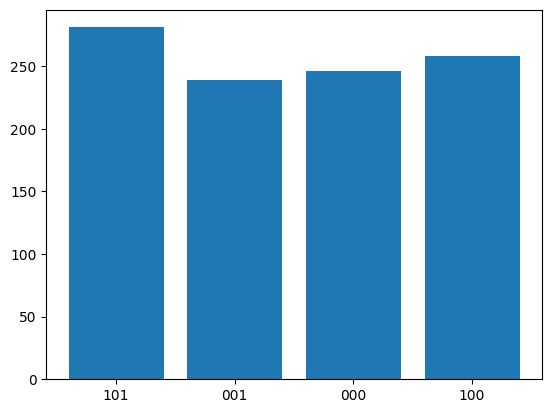

In [97]:
upper_reg = [0,1,2]
lower_reg = [3,4,5]
s = [1, 0, 1]
qc = QuantumCircuit(6,3)
qc.h(upper_reg)
qc.barrier()
for i in range(3):
    if s[i] == 1:
        qc.cx(i, i + 3)
qc.barrier()
qc.h(upper_reg)

qc.measure(upper_reg, [0,1,2])


# Simulate the circuit
simulator = AerSimulator()
counts = simulator.run(qc, shots=1024).result().get_counts()
plt.bar(counts.keys(), counts.values())

poté negace $s$ je ortogonální na všechny naměřené hodnoty (tj. "skalární součin $\sum!s_i r_i$ je roven nule")

<BarContainer object of 8 artists>

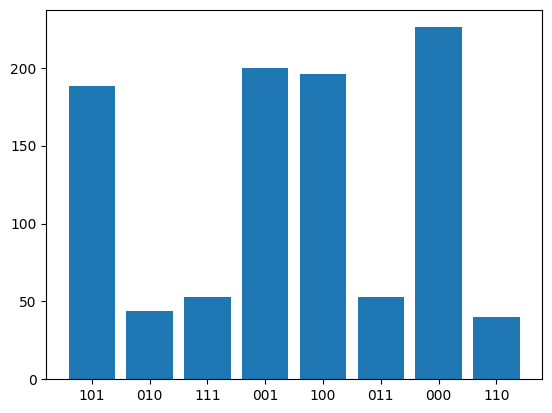

In [212]:
pm = generate_preset_pass_manager(backend = backend, optimization_level=0)
sampler = Sampler(mode=backend)
isa_circuits = pm.run([qc])
job = sampler.run(isa_circuits, shots = 1000) 
counts = job.result()[0].data.c.get_counts()
plt.bar(counts.keys(), counts.values())

Neperiodická funkce

<BarContainer object of 8 artists>

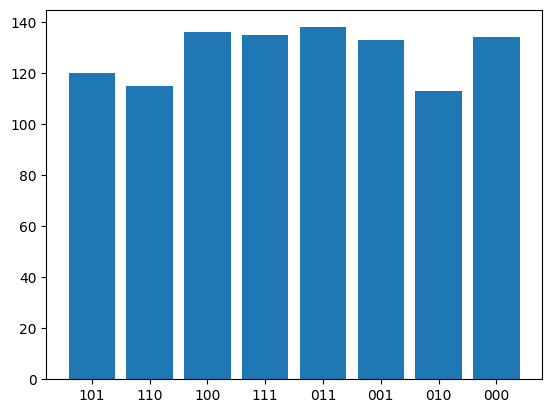

In [213]:
qc = QuantumCircuit(6, 3)
qc.h(upper_reg)
qc.barrier()
qc.cx(1, 3)
qc.cx(1, 4)
qc.cx(1, 5)
qc.cx(2, 3)
qc.cx(2, 4)
qc.cx(0, 3)
qc.barrier()
qc.h(upper_reg)
qc.measure(upper_reg, [0,1,2])
# Simulate the circuit
simulator = AerSimulator()
counts = simulator.run(qc, shots=1024).result().get_counts()
plt.bar(counts.keys(), counts.values())

Neexistuje nějaký (nenulový) bitový vzorec, který by při "ortogonálním součinu" hodil 0 u všech naměřených kombinací. Tzn. neexistuje "kolmý bistring".

<BarContainer object of 8 artists>

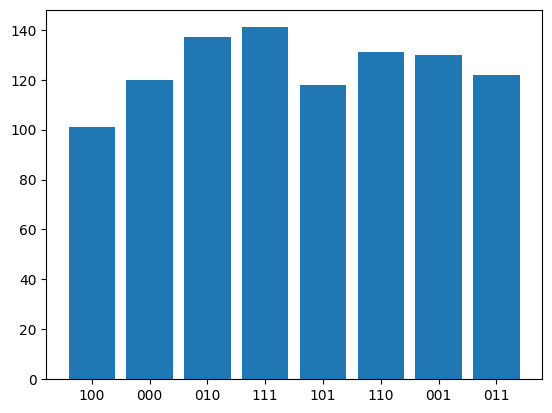

In [214]:
pm = generate_preset_pass_manager(backend = backend, optimization_level=0)
sampler = Sampler(mode=backend)
isa_circuits = pm.run([qc])
job = sampler.run(isa_circuits, shots = 1000) 
counts = job.result()[0].data.c.get_counts()
plt.bar(counts.keys(), counts.values())

Výstup z prvního obvodu na kvantovém počítači je zatížen šumem, tudíž proto se zde vyskytují i ne-simulované bitstringy. Tento šum nejde poznat u druhého obvodu neboť i v simulátoru jsme naměřili každý bitstring s hodnotami, které naznačují uniformní rozdělení -> náhodné bitflipy by neměly změnit výsledek.

Komentáře k pediodicitě a neperiodicitě jdou u příslušných obvodů.